In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import seaborn as sns

from scipy.stats import gaussian_kde
from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
product, time_reso, reso = 'IMERG', '1dy', '10'

In [3]:
dir_input = os.path.join('/','media','arturo','T9','Data','INTENSE','Satellite','2_MEV', 'uncorrected')
dir_output = os.path.join('/','media','arturo','T9','Data','INTENSE','Satellite','2_MEV', 'corrected')
obs_base = os.path.join('/','media','arturo','T9','Data','INTENSE','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [4]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
lon_min, lon_max, lat_min, lat_max, area = 12.25, 14, 45.5, 46.65, 'Friuli-Venezia Giulia'

In [5]:
# yys, yye = 2002, 2022
yys, yye = 2009, 2022

In [6]:
inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
DATA = xr.open_dataset(os.path.join(dir_input, 'quantiles_v2', inputfile))

DATA = DATA.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max),
    year=slice(yys, yye)
)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

MEV = DATA.Mev_s.where(mask_italy).values

In [7]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))

METADATA['Yr_Strt'] = pd.to_datetime(METADATA['Yr_Strt'])
METADATA['Yer_End'] = pd.to_datetime(METADATA['Yer_End'])

METADATA['YYs'] = METADATA['Yr_Strt'].dt.year
METADATA['YYe'] = METADATA['Yer_End'].dt.year
METADATA['Nyear'] = (METADATA['YYe']-METADATA['YYs'])+1

METADATA_CLEAR = METADATA[(METADATA['YYs'] <= yys)&(METADATA['YYe'] >= yye)]

# METADATA_CLEAR = METADATA_CLEAR[METADATA_CLEAR.Nyear>19]

METADATA_CLEAR = METADATA_CLEAR[METADATA_CLEAR['Region']=='Friuli-Venezia Giulia']

print(f'Number of Stations filtered: {len(METADATA_CLEAR)}')

Number of Stations filtered: 159


In [8]:
p_train, p_val, label = 100, 100, '100_100'
# p_train, p_val, label = 90, 10, '90_10'
# p_train, p_val, label = 80, 20, '80_20'
# p_train, p_val, label = 70, 30, '70_30'
# p_train, p_val, label = 50, 50, '50_50'

In [9]:
pos = 3
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)
print(f'Return Time: {Tr[pos]} yrs')

Return Time: 50 yrs


In [ ]:
def bias_annual(DF_input):
    factor_N_annual = []
    factor_C_annual = []
    factor_W_annual = []

    for nn in range(len(DF_input)):

        file = DF_input['File'].iloc[nn]
        ISO = DF_input['ISO'].iloc[nn]
        lon_obs = DF_input['Lon'].iloc[nn]
        lat_obs = DF_input['Lat'].iloc[nn]

        # Observations
        DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

        DF_OBS = DF_OBS.drop(columns='NaN')

        # IMERG nearest pixel
        sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

        DF_SAT = pd.DataFrame({'Year': sat_pixel.year.values,'Ns': sat_pixel.NYs.values,'Cs': sat_pixel.CYs.values,'Ws': sat_pixel.WYs.values})

        # Merge by year
        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N', 'C', 'W', 'Ns', 'Cs', 'Ws'])

        # Annual correction factors
        merged_df_clean['factor_N'] = (merged_df_clean['N'] / merged_df_clean['Ns'])
        merged_df_clean['factor_C'] = (merged_df_clean['C'] / merged_df_clean['Cs'])
        merged_df_clean['factor_W'] = (merged_df_clean['W'] / merged_df_clean['Ws'])

        # Add spatial information
        merged_df_clean['lon'] = lon_obs
        merged_df_clean['lat'] = lat_obs

        # Store only the required columns
        factor_N_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_N']])
        factor_C_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_C']])
        factor_W_annual.append(merged_df_clean[['Year', 'lon', 'lat', 'factor_W']])

    df_N = pd.concat(factor_N_annual,ignore_index=True)
    df_C = pd.concat(factor_C_annual,ignore_index=True)
    df_W = pd.concat(factor_W_annual,ignore_index=True)
    
    return df_N, df_C, df_W

def bias_annual_mean(DF_input):
    lat_list, lon_list = [], []
    factor_N_list, factor_C_list, factor_W_list = [], [], []

    for nn in range(len(DF_input)):

        file = DF_input['File'].iloc[nn]
        ISO = DF_input['ISO'].iloc[nn]
        lon_obs = DF_input['Lon'].iloc[nn]
        lat_obs = DF_input['Lat'].iloc[nn]

        # Observations
        DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

        DF_OBS = DF_OBS.drop(columns='NaN')

        # IMERG nearest pixel
        sat_pixel = DATA.sel(lat=lat_obs,lon=lon_obs,method='nearest')

        DF_SAT = pd.DataFrame({'Year': sat_pixel.year.values,'Ns': sat_pixel.NYs.values,'Cs': sat_pixel.CYs.values,'Ws': sat_pixel.WYs.values})

        # Merge by year
        merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

        merged_df_clean = merged_df.dropna(subset=['N', 'C', 'W', 'Ns', 'Cs', 'Ws'])

        # Annual correction factors
        # En este caso, la corrección ajusta el nivel medio, pero no reproduce necesariamente las variaciones interanuales observadas.
        factor_N = np.nanmean(merged_df_clean['N'] / merged_df_clean['Ns'])
        factor_C = np.nanmean(merged_df_clean['C'] / merged_df_clean['Cs'])
        factor_W = np.nanmean(merged_df_clean['W'] / merged_df_clean['Ws'])

        # Add spatial information
        merged_df_clean['lon'] = lon_obs
        merged_df_clean['lat'] = lat_obs

        lat_list.append(lat_obs)
        lon_list.append(lon_obs)
        factor_N_list.append(factor_N)
        factor_C_list.append(factor_C)
        factor_W_list.append(factor_W)

    Factor_N_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_N_list})
    Factor_C_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_C_list})
    Factor_W_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_W_list})
    
    factor_N_grid = ART_stat.interpolate_factors_to_grid(Factor_N_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_N_grid = factor_N_grid.where(mask_italy).values

    factor_C_grid = ART_stat.interpolate_factors_to_grid(Factor_C_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_C_grid = factor_C_grid.where(mask_italy).values

    factor_W_grid = ART_stat.interpolate_factors_to_grid(Factor_W_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
    factor_W_grid = factor_W_grid.where(mask_italy).values
    
    return factor_N_grid, factor_C_grid, factor_W_grid

In [11]:
primos_50 = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71,
            73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151,
            157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229]

np.random.seed(123)
aleatorios_50 = np.random.choice(range(1000, 10000), size=50, replace=False).tolist()

seeds = primos_50 + aleatorios_50

In [12]:
# sys.exit()

In [13]:
for seed in seeds:
    print(f'Seed: {seed}')

    if p_train == 100:
        DF_80 = METADATA_CLEAR.copy()
        DF_20 = METADATA_CLEAR.copy()
    elif p_train == 90:
        DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.10,random_state=seed,shuffle=True)
    elif p_train == 80:
        DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.20,random_state=seed,shuffle=True)
    elif p_train == 70:
        DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.30,random_state=seed,shuffle=True)
    elif p_train == 50:
        DF_80, DF_20 = train_test_split(METADATA_CLEAR,test_size=0.50,random_state=seed,shuffle=True)
    # print(f'Percetange to train: {p_train}%')

    NYs = DATA.NYs.where(mask_italy).values
    CYs = DATA.CYs.where(mask_italy).values
    WYs = DATA.WYs.where(mask_italy).values

    DF_80['color'] = 'royalblue'
    DF_20['color'] = 'salmon'

    METADATA_CLEAR.loc[DF_80.index, 'color'] = 'royalblue'
    METADATA_CLEAR.loc[DF_20.index, 'color'] = 'salmon'

    # ===============================================================================================================
    # Mean correction
    Factor_N_grid, Factor_C_grid, Factor_W_grid = bias_annual_mean(DF_80)
    NYs_corrected = NYs * Factor_N_grid
    CYs_corrected = CYs * Factor_C_grid
    WYs_corrected = WYs * Factor_W_grid

    Corrected_mean = xr.Dataset(data_vars={
                        "NYs_corrected": (("year","lat","lon"), NYs_corrected),
                        "CYs_corrected": (("year","lat","lon"), CYs_corrected),
                        "WYs_corrected": (("year","lat","lon"), WYs_corrected),
                        },
                        coords={'year':years,'lat': lats, 'lon': lons})

    # ===============================================================================================================
    # Annual correction
    Factor_N_annual_df, Factor_C_annual_df, Factor_W_annual_df = bias_annual(DF_80)

    years = np.arange(yys, yye+1)

    factor_N_grids = []
    factor_C_grids = []
    factor_W_grids = []

    for year in years:

        # Select one year
        Factor_N_year = Factor_N_annual_df[Factor_N_annual_df['Year'] == year][['lon', 'lat', 'factor_N']].copy()
        Factor_C_year = Factor_C_annual_df[Factor_C_annual_df['Year'] == year][['lon', 'lat', 'factor_C']].copy()
        Factor_W_year = Factor_W_annual_df[Factor_W_annual_df['Year'] == year][['lon', 'lat', 'factor_W']].copy()

        # Rename factor columns
        Factor_N_year = Factor_N_annual_df[Factor_N_annual_df['Year'] == year][['lon', 'lat', 'factor_N']].rename(columns={'factor_N': 'factor'})
        Factor_C_year = Factor_C_annual_df[Factor_C_annual_df['Year'] == year][['lon', 'lat', 'factor_C']].rename(columns={'factor_C': 'factor'})
        Factor_W_year = Factor_W_annual_df[Factor_W_annual_df['Year'] == year][['lon', 'lat', 'factor_W']].rename(columns={'factor_W': 'factor'})

        # Interpolation
        factor_N_grid_year = (
            ART_stat.interpolate_factors_to_grid(
                Factor_N_year,
                DATA,
                use_idw=True,
                power=2,
                n_neighbors=2,
                max_distance=5.0).where(mask_italy))

        factor_C_grid_year = (
            ART_stat.interpolate_factors_to_grid(
                Factor_C_year,
                DATA,
                use_idw=True,
                power=2,
                n_neighbors=2,
                max_distance=5.0).where(mask_italy))

        factor_W_grid_year = (
            ART_stat.interpolate_factors_to_grid(
                Factor_W_year,
                DATA,
                use_idw=True,
                power=2,
                n_neighbors=2,
                max_distance=5.0).where(mask_italy))

        factor_N_grids.append(factor_N_grid_year)
        factor_C_grids.append(factor_C_grid_year)
        factor_W_grids.append(factor_W_grid_year)

    factor_N_grid = xr.concat(factor_N_grids,dim=pd.Index(years, name='year'))
    factor_C_grid = xr.concat(factor_C_grids,dim=pd.Index(years, name='year'))
    factor_W_grid = xr.concat(factor_W_grids,dim=pd.Index(years, name='year'))

    NYs = DATA.NYs.where(mask_italy)
    CYs = DATA.CYs.where(mask_italy)
    WYs = DATA.WYs.where(mask_italy)

    NY_corrected_annual = NYs * factor_N_grid
    CY_corrected_annual = CYs * factor_C_grid
    WY_corrected_annual = WYs * factor_W_grid

    Corrected_annual = xr.Dataset(data_vars={
                        "NYs_corrected_annual": (("year","lat","lon"), NY_corrected_annual.values),
                        "CYs_corrected_annual": (("year","lat","lon"), CY_corrected_annual.values),
                        "WYs_corrected_annual": (("year","lat","lon"), WY_corrected_annual.values),
                        },
                        coords={'year':years,'years':Tr,'lat': lats, 'lon': lons})

    RE_mean = []
    Nobs_all, Cobs_all, Wobs_all = [], [], []
    Ncor_all, Ccor_all, Wcor_all = [], [], []

    DF_mean_individual = []

    for nn in range(len(DF_20)):

        lon_obs = DF_20['Lon'].iloc[nn]
        lat_obs = DF_20['Lat'].iloc[nn]

        # Seleccionar el píxel IMERG más cercano
        sat_pixel = Corrected_mean.sel(lat=lat_obs,lon=lon_obs,method='nearest')

        N_corrected_station = sat_pixel.NYs_corrected
        C_corrected_station = sat_pixel.CYs_corrected
        W_corrected_station = sat_pixel.WYs_corrected

        # Leer datos observados
        file = DF_20['File'].iloc[nn]
        ISO = DF_20['ISO'].iloc[nn]

        DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

        DF_OBS = DF_OBS.drop(columns='NaN')

        # Crear DataFrame con los parámetros corregidos
        comparison_mean = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

        # Añadir parámetros observados
        comparison_mean = comparison_mean.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
        comparison_mean_clean = comparison_mean.copy()
        comparison_mean_clean = comparison_mean_clean.dropna()
        
        DF_mean_individual.append(comparison_mean.copy())

        Nobs_all.extend(comparison_mean.N.values)
        Cobs_all.extend(comparison_mean.C.values)
        Wobs_all.extend(comparison_mean.W.values)

        Ncor_all.extend(comparison_mean.N_corrected.values)
        Ccor_all.extend(comparison_mean.C_corrected.values)
        Wcor_all.extend(comparison_mean.W_corrected.values)

        x0 = np.nanmean(comparison_mean_clean.C.values)
        Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison_mean_clean.N.values, comparison_mean_clean.C.values, comparison_mean_clean.W.values, thresh=1)

        x0 = np.nanmean(comparison_mean_clean.C_corrected.values)
        Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison_mean_clean.N_corrected.values, comparison_mean_clean.C_corrected.values, comparison_mean_clean.W_corrected.values, thresh=1)

        RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
        RE_mean.append(RE_)
        
    DF_mean = pd.DataFrame({'N':Nobs_all, 'C':Cobs_all, 'W':Wobs_all, 'NYs':Ncor_all, 'CYs':Ccor_all, 'WYs':Wcor_all})

    RE_annual = []
    Nobs_all, Cobs_all, Wobs_all = [], [], []
    Ncor_all, Ccor_all, Wcor_all = [], [], []

    DF_annual_individual = []

    for nn in range(len(DF_20)):

        lon_obs = DF_20['Lon'].iloc[nn]
        lat_obs = DF_20['Lat'].iloc[nn]

        # Seleccionar el píxel IMERG más cercano
        sat_pixel = Corrected_annual.sel(lat=lat_obs,lon=lon_obs,method='nearest')

        N_corrected_station = sat_pixel.NYs_corrected_annual
        C_corrected_station = sat_pixel.CYs_corrected_annual
        W_corrected_station = sat_pixel.WYs_corrected_annual

        # Leer datos observados
        file = DF_20['File'].iloc[nn]
        ISO = DF_20['ISO'].iloc[nn]

        DF_OBS = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', ISO, file))

        DF_OBS = DF_OBS.drop(columns='NaN')

        # Crear DataFrame con los parámetros corregidos
        comparison_annual = pd.DataFrame({'Year': N_corrected_station.year.values,'N_corrected': N_corrected_station.values,'C_corrected': C_corrected_station.values,'W_corrected': W_corrected_station.values})

        # Añadir parámetros observados
        comparison_annual = comparison_annual.merge(DF_OBS[['Year', 'N', 'C', 'W']],on='Year',how='left')
        comparison_annual_clean = comparison_annual.copy()
        comparison_annual_clean = comparison_annual_clean.dropna()

        DF_annual_individual.append(comparison_annual.copy())

        Nobs_all.extend(comparison_annual.N.values)
        Cobs_all.extend(comparison_annual.C.values)
        Wobs_all.extend(comparison_annual.W.values)

        Ncor_all.extend(comparison_annual.N_corrected.values)
        Ccor_all.extend(comparison_annual.C_corrected.values)
        Wcor_all.extend(comparison_annual.W_corrected.values)

        x0 = np.nanmean(comparison_annual_clean.C.values)
        Q_obs = DOWN_raw.mev_quant_update(Fi, x0, comparison_annual_clean.N.values, comparison_annual_clean.C.values, comparison_annual_clean.W.values, thresh=1)

        x0 = np.nanmean(comparison_annual_clean.C_corrected.values)
        Q_corrected = DOWN_raw.mev_quant_update(Fi, x0, comparison_annual_clean.N_corrected.values, comparison_annual_clean.C_corrected.values, comparison_annual_clean.W_corrected.values, thresh=1)

        RE_ = (Q_corrected[0][3] - Q_obs[0][3])/Q_obs[0][3]
        RE_annual.append(RE_)

    DF_annual = pd.DataFrame({'N':Nobs_all, 'C':Cobs_all, 'W':Wobs_all, 'NYs':Ncor_all, 'CYs':Ccor_all, 'WYs':Wcor_all})
    
    DF_RE = pd.DataFrame({
    'Mean': pd.Series(RE_mean, dtype='float64'),
    'Annual': pd.Series(RE_annual, dtype='float64')})
    df_out = os.path.join('..','..','output','RE_bias','Fiuri_venezia',label,f'RE_{seed}.csv')
    DF_RE.to_csv(df_out, header=True, index=False)

Seed: 2
Seed: 3
Seed: 5
Seed: 7
Seed: 11
Seed: 13
Seed: 17
Seed: 19
Seed: 23
Seed: 29
Seed: 31
Seed: 37
Seed: 41
Seed: 43
Seed: 47
Seed: 53
Seed: 59
Seed: 61
Seed: 67
Seed: 71
Seed: 73
Seed: 79
Seed: 83
Seed: 89
Seed: 97
Seed: 101
Seed: 103
Seed: 107
Seed: 109
Seed: 113
Seed: 127
Seed: 131
Seed: 137
Seed: 139
Seed: 149
Seed: 151
Seed: 157
Seed: 163
Seed: 167
Seed: 173
Seed: 179
Seed: 181
Seed: 191
Seed: 193
Seed: 197
Seed: 199
Seed: 211
Seed: 223
Seed: 227
Seed: 229
Seed: 2603
Seed: 9472
Seed: 3213
Seed: 1498
Seed: 2038
Seed: 9399
Seed: 4324
Seed: 8535
Seed: 2519
Seed: 2959
Seed: 6111
Seed: 5759
Seed: 5559
Seed: 2672
Seed: 9558
Seed: 2475
Seed: 9781
Seed: 9676
Seed: 6226
Seed: 8110
Seed: 9711
Seed: 8081
Seed: 8868
Seed: 5112
Seed: 5088
Seed: 6243
Seed: 5497
Seed: 9966
Seed: 9683
Seed: 8006
Seed: 5403
Seed: 5570
Seed: 5612
Seed: 7396
Seed: 2515
Seed: 4278
Seed: 2384
Seed: 5899
Seed: 5957
Seed: 4340
Seed: 5889
Seed: 2778
Seed: 3176
Seed: 8319
Seed: 6939
Seed: 7763
Seed: 9199
Seed: 9866
S

In [14]:
DF_RE_list = glob.glob(os.path.join('..','..','output','RE_bias','Fiuri_venezia',label,f'*.csv'))
DF_RE_list = sorted(DF_RE_list)
DF_RE_len = len(DF_RE_list)

In [15]:
RE_mean, RE_annual = None, None
for nn in range(DF_RE_len):
    RE_data = pd.read_csv(DF_RE_list[nn])
    if RE_mean is None:
        RE_mean = np.zeros([len(RE_data),DF_RE_len])*np.nan
        RE_annual = np.zeros([len(RE_data),DF_RE_len])*np.nan

    RE_mean[:,nn] = np.array(RE_data['Mean'].values)
    RE_annual[:,nn] = np.array(RE_data['Annual'].values)

RE_mean[np.isinf(RE_mean)] = np.nan
RE_annual[np.isinf(RE_annual)] = np.nan

Export as: ../../figures/factor/Fiuri_venezia/IMERG_100_100_RE_BIAS_2.png


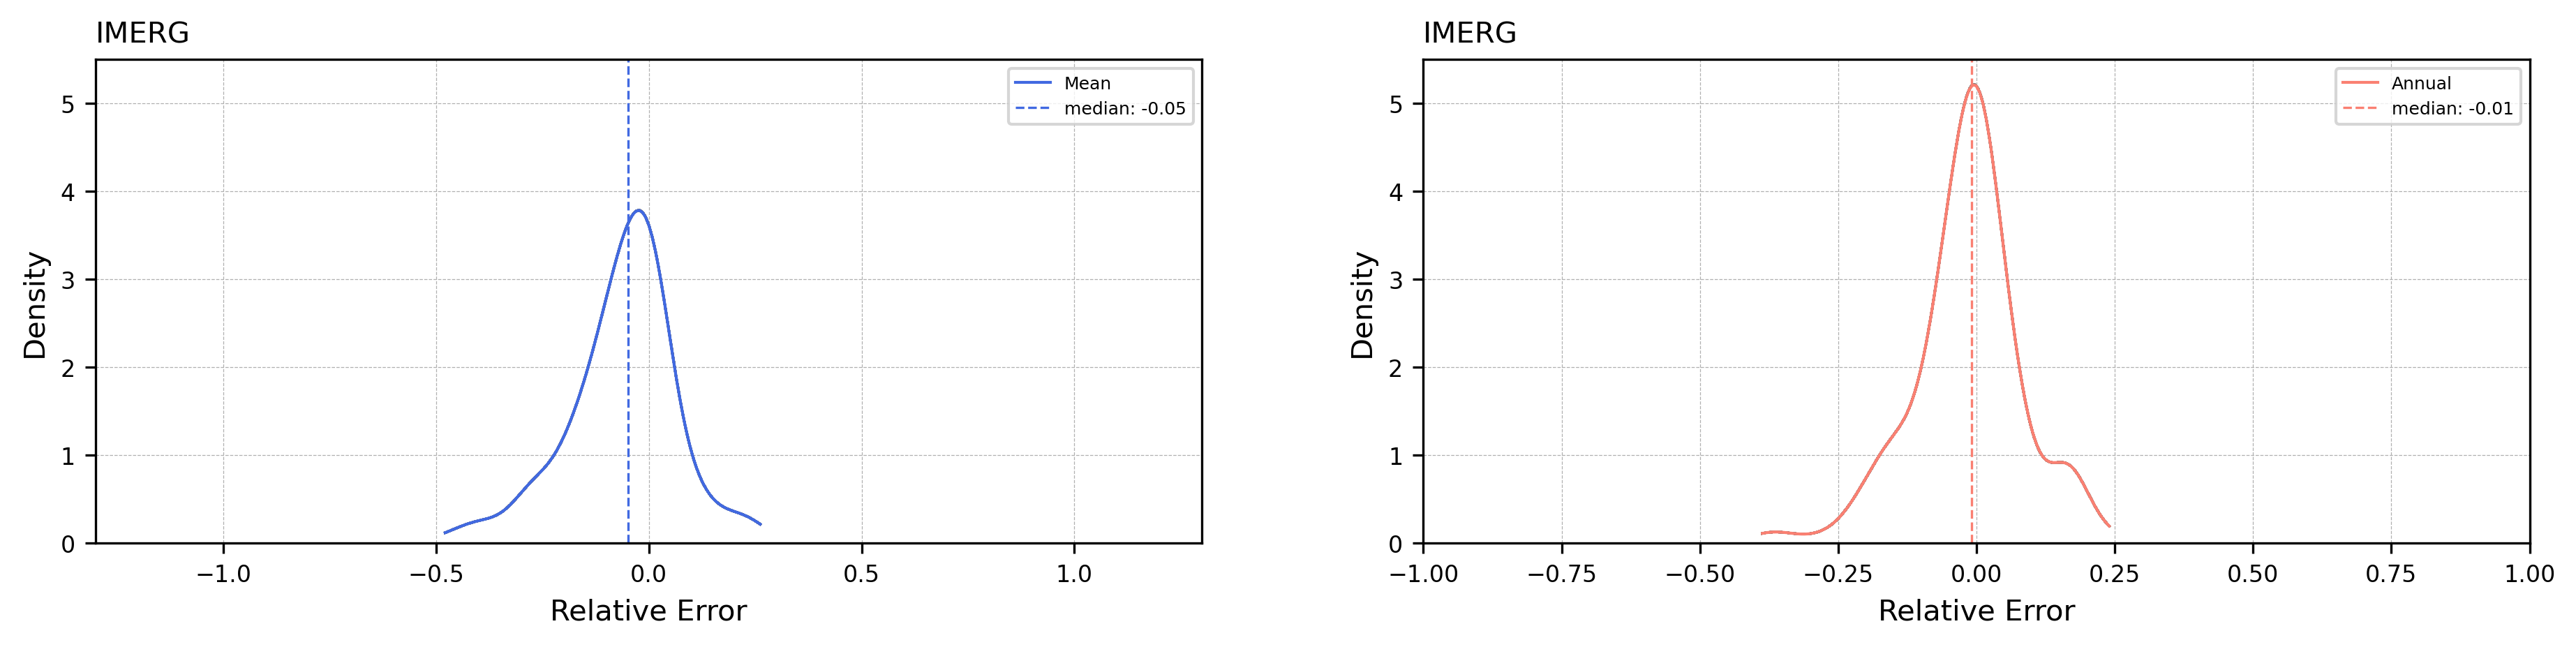

In [16]:
fig = plt.figure(figsize=(15,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])

for nn in range(RE_mean.shape[1]):
    sns.kdeplot(RE_mean[:, nn], color='gray', alpha=0.3, linewidth=0.8, ax=ax1,
                clip=(np.nanmin(np.array(RE_mean[:, nn])), np.nanmax(np.array(RE_mean[:, nn]))))

# x_grid = np.linspace(np.nanmin(RE_mean), np.nanmax(RE_mean), 500)
x_grid = np.linspace(np.nanmin(RE_mean), np.nanmax(RE_mean), 100)

kde_values = np.zeros((len(x_grid), RE_mean.shape[1]))

for nn in range(RE_mean.shape[1]):
    data = RE_mean[:, nn][np.isfinite(RE_mean[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

median_kde_mean = np.nanmedian(kde_values, axis=1)
p25_kde = np.nanpercentile(kde_values, 25, axis=1)
p75_kde = np.nanpercentile(kde_values, 75, axis=1)

ax1.plot(x_grid, median_kde_mean, color='royalblue', linewidth=1, label='Mean')
ax1.axvline(x=np.nanmedian(RE_mean,axis=[0,1]), color='royalblue', linestyle='--', linewidth=0.8, label=f'median: {np.round(np.nanmedian(RE_mean,axis=[0,1]),2)}')
# ax1.fill_between(x_grid, p25_kde, p75_kde, alpha=0.2, color='red',zorder=40)

ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Density')
ax1.set_title(f'{product}',loc='left',fontsize=10)
# ax1.set_title(f'{fraction}',loc='center',fontsize=10)
# ax1.set_title(f'Total seeds: {seed_len}',loc='right',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1.3,1.3)
# ax1.set_ylim(0,2.6)
ax1.set_ylim(0,5.5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1])

for nn in range(RE_annual.shape[1]):
    sns.kdeplot(RE_annual[:, nn], color='gray', alpha=0.3, linewidth=0.8, ax=ax1,
                clip=(np.nanmin(np.array(RE_annual[:, nn])), np.nanmax(np.array(RE_annual[:, nn]))))

# x_grid = np.linspace(np.nanmin(RE_annual), np.nanmax(RE_annual), 500)
x_grid = np.linspace(np.nanmin(RE_annual), np.nanmax(RE_annual), 100)

kde_values = np.zeros((len(x_grid), RE_annual.shape[1]))

for nn in range(RE_annual.shape[1]):
    data = RE_annual[:, nn][np.isfinite(RE_annual[:, nn])]
    if len(data) > 1:
        kde = gaussian_kde(data)
        kde_values[:, nn] = kde(x_grid)

median_kde_annual = np.nanmedian(kde_values, axis=1)
p25_kde = np.nanpercentile(kde_values, 25, axis=1)
p75_kde = np.nanpercentile(kde_values, 75, axis=1)

ax1.plot(x_grid, median_kde_annual, color='salmon', linewidth=1, label='Annual')
ax1.axvline(x=np.nanmedian(RE_annual,axis=[0,1]), color='salmon', linestyle='--', linewidth=0.8, label=f'median: {np.round(np.nanmedian(RE_annual,axis=[0,1]),2)}')
# ax1.fill_between(x_grid, p25_kde, p75_kde, alpha=0.2, color='red',zorder=40)

ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Density')
ax1.set_title(f'{product}',loc='left',fontsize=10)
# ax1.set_title(f'{fraction}',loc='center',fontsize=10)
# ax1.set_title(f'Total seeds: {seed_len}',loc='right',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1,1)
# ax1.set_ylim(0,2.6)
ax1.set_ylim(0,5.5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

dir_out = os.path.join('..','..','figures','factor','Fiuri_venezia',f'IMERG_{label}_RE_BIAS_2.png')
print(F'Export as: {dir_out}')
plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

Export as: ../../figures/factor/Fiuri_venezia/IMERG_100_100_RE_BIAS_1.png


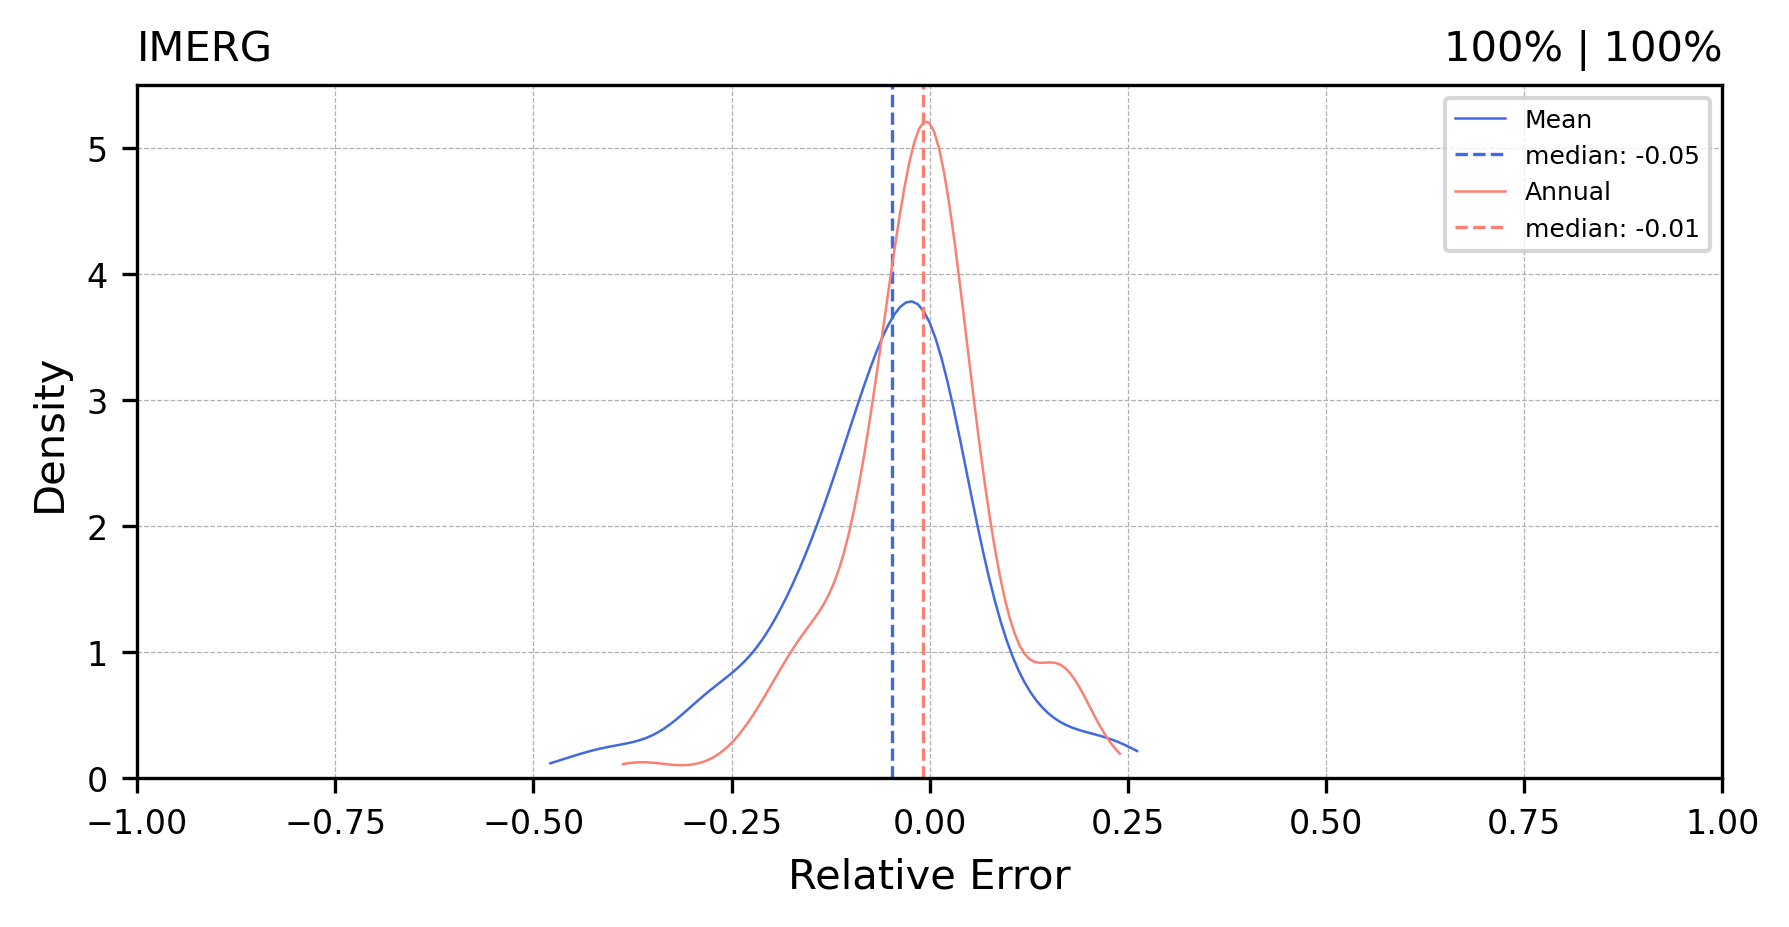

In [17]:
fig = plt.figure(figsize=(15,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])
x_grid = np.linspace(np.nanmin(RE_mean), np.nanmax(RE_mean), 100)
ax1.plot(x_grid, median_kde_mean, color='royalblue', linewidth=0.6, label='Mean')
ax1.axvline(x=np.nanmedian(RE_mean,axis=[0,1]), color='royalblue', linestyle='--', linewidth=0.8, label=f'median: {np.round(np.nanmedian(RE_mean,axis=[0,1]),2)}')

x_grid = np.linspace(np.nanmin(RE_annual), np.nanmax(RE_annual), 100)
ax1.plot(x_grid, median_kde_annual, color='salmon', linewidth=0.6, label='Annual')
ax1.axvline(x=np.nanmedian(RE_annual,axis=[0,1]), color='salmon', linestyle='--', linewidth=0.8, label=f'median: {np.round(np.nanmedian(RE_annual,axis=[0,1]),2)}')

ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Density')
ax1.set_title(f'{product}',loc='left',fontsize=10)
# ax1.set_title(f'{fraction}',loc='center',fontsize=10)
# ax1.set_title(f'Total seeds: {seed_len}',loc='right',fontsize=10)
ax1.legend(fontsize=6,loc=1)
ax1.set_xlim(-1,1)
ax1.set_title(f'{p_train}% | {p_val}%',fontsize=10, loc='right')
ax1.set_ylim(0,5.5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)

dir_out = os.path.join('..','..','figures','factor','Fiuri_venezia',f'IMERG_{label}_RE_BIAS_1.png')
print(F'Export as: {dir_out}')
plt.savefig(dir_out,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

NameError: name 'merged_df_clean' is not defined